In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/neurosense_cleaned.csv")

print(df.shape)
df.head()

(37575, 361)


,eeg_feature_1,eeg_feature_2,eeg_feature_3,eeg_feature_4,eeg_feature_5,eeg_feature_6,eeg_feature_7,eeg_feature_8,eeg_feature_9,eeg_feature_10,...,eye_range,eeg_stability,eye_stability,phys_activity,label,emotion,subject,session,trial,sample
0,26.791522,24.062115,21.927618,19.697461,18.626858,26.781416,24.090212,21.992052,19.634864,18.446852,...,6148.7,6.623193,0.289054,359.072631,1,Sad,10,1,1,0
1,26.791101,24.061706,21.928215,19.697127,18.626882,26.780972,24.089481,21.992834,19.634719,18.447054,...,6148.7,6.622985,0.289050,359.068374,1,Sad,10,1,1,1
2,26.791650,24.062570,21.929218,19.696753,18.626936,26.783116,24.090431,21.994368,19.634771,18.447366,...,6148.7,6.622051,0.289049,359.067974,1,Sad,10,1,1,2
3,26.793695,24.063827,21.931248,19.696395,18.626931,26.787306,24.092226,21.997363,19.634678,18.447735,...,6148.7,6.620988,0.289037,359.054303,1,Sad,10,1,1,3
4,26.794138,24.064473,21.933663,19.696645,18.627109,26.790289,24.093457,22.000899,19.635314,18.448518,...,6148.7,6.619975,0.289018,359.032246,1,Sad,10,1,1,4


In [2]:

X = df.drop(columns=["label", "subject", "session", "trial", "sample"], errors="ignore")
y = df["label"]

X = X.select_dtypes(include=["number"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

groups = df["subject"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X shape: (37575, 355)
y shape: (37575,)
label
0    9750
2    9735
1    9525
3    8565
Name: count, dtype: int64
Train shape: (30060, 355)
Test shape: (7515, 355)


In [3]:
# Decision Tree bazik

dt_basic = DecisionTreeClassifier(
    random_state=42
)

dt_basic.fit(X_train, y_train)

y_pred_dt_basic = dt_basic.predict(X_test)

In [4]:
# Vlerësimi i Decision Tree bazik

dt_basic_results = {
    "Model": "Decision Tree Basic",
    "Accuracy": accuracy_score(y_test, y_pred_dt_basic),
    "Precision": precision_score(y_test, y_pred_dt_basic, average="weighted"),
    "Recall": recall_score(y_test, y_pred_dt_basic, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_dt_basic, average="weighted")
}

print("Decision Tree Basic Results")
for key, value in dt_basic_results.items():
    print(key, ":", value)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_basic))

Decision Tree Basic Results
Model : Decision Tree Basic
Accuracy : 0.30379241516966066
Precision : 0.31819530387374495
Recall : 0.30379241516966066
F1-score : 0.3026001377278465

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.39      0.40      1950
           1       0.23      0.37      0.29      1905
           2       0.30      0.26      0.27      1947
           3       0.32      0.19      0.24      1713

    accuracy                           0.30      7515
   macro avg       0.32      0.30      0.30      7515
weighted avg       0.32      0.30      0.30      7515



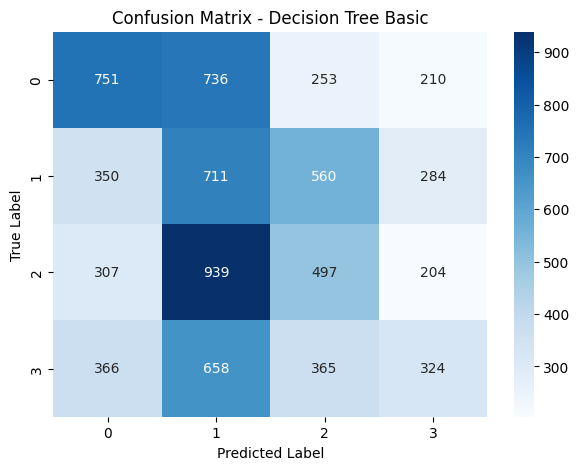

In [5]:
#Confusion Matrix për Decision Tree bazik

cm_basic = confusion_matrix(y_test, y_pred_dt_basic)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_basic, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree Basic")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [6]:
# Feature Importance

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_basic.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(20)


,Feature,Importance
310,eye_feature_1,0.058829
346,std_eye,0.050390
317,eye_feature_8,0.031635
291,eeg_feature_292,0.018482
67,eeg_feature_68,0.016758
345,avg_eye,0.016739
338,eye_feature_29,0.015451
181,eeg_feature_182,0.015176
16,eeg_feature_17,0.015014
330,eye_feature_21,0.014311


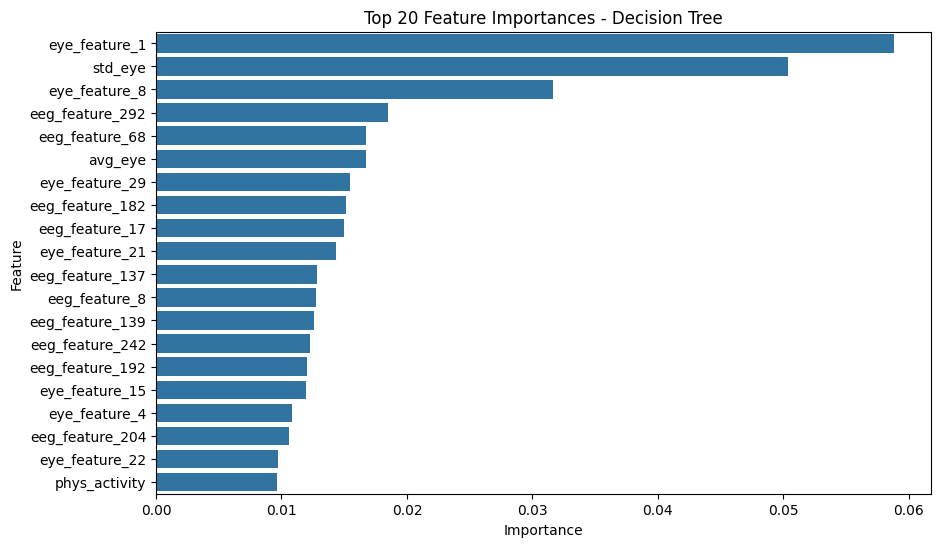

In [7]:
# Vizualizimi i Top 20 Feature Importance

top_20_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_20_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [8]:
# Hyperparameter Tuning për Decision Tree

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search_dt.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search_dt.best_params_)

print("Best CV Score:")
print(grid_search_dt.best_score_)

Fitting 3 folds for each of 90 candidates, totalling 270 fits
Best Parameters:
{'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score:
0.2697132967414663


In [9]:
#  Vlerësimi final i Decision Tree pas tuning

best_dt_model = grid_search_dt.best_estimator_

y_pred_best_dt = best_dt_model.predict(X_test)

dt_final_results = {
    "Model": "Decision Tree + GridSearchCV",
    "Accuracy": accuracy_score(y_test, y_pred_best_dt),
    "Precision": precision_score(y_test, y_pred_best_dt, average="weighted"),
    "Recall": recall_score(y_test, y_pred_best_dt, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_best_dt, average="weighted"),
    "Best Parameters": grid_search_dt.best_params_
}

print("Final Decision Tree Results")
for key, value in dt_final_results.items():
    print(key, ":", value)

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_best_dt))

Final Decision Tree Results
Model : Decision Tree + GridSearchCV
Accuracy : 0.30379241516966066
Precision : 0.31819530387374495
Recall : 0.30379241516966066
F1-score : 0.3026001377278465
Best Parameters : {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

Final Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.39      0.40      1950
           1       0.23      0.37      0.29      1905
           2       0.30      0.26      0.27      1947
           3       0.32      0.19      0.24      1713

    accuracy                           0.30      7515
   macro avg       0.32      0.30      0.30      7515
weighted avg       0.32      0.30      0.30      7515



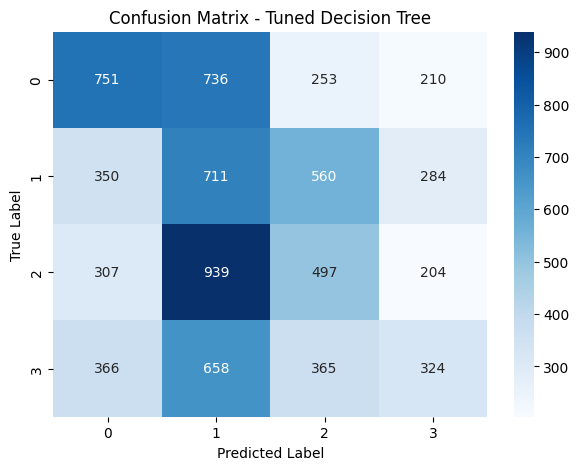

In [10]:
#  Confusion Matrix final

cm_final = confusion_matrix(y_test, y_pred_best_dt)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [11]:
# 13. Krahasimi Basic vs Tuned

dt_comparison_df = pd.DataFrame([
    dt_basic_results,
    dt_final_results
])

dt_comparison_df


dt_results_df = pd.DataFrame([dt_final_results])

dt_results_df.to_csv("../results/tables/decision_tree_results.csv", index=False)
dt_comparison_df.to_csv("../results/tables/decision_tree_comparison_results.csv", index=False)

dt_results_df

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,Decision Tree + GridSearchCV,0.303792,0.318195,0.303792,0.3026,"{'criterion': 'gini', 'max_depth': 15, 'min_sa..."
